<a href="https://colab.research.google.com/github/azhgh22/SentimentAnalysis/blob/main/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Set Env in Colab**

In [ ]:
%%capture
from google.colab import drive
drive.mount('/content/drive')

from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')
user_name = userdata.get('GITHUB_USERNAME')
mail = userdata.get('GITHUB_MAIL')

!git config --global user.name "{user_name}"
!git config --global user.email "{mail}"
!git clone https://{token}@github.com/azhgh22/SentimentAnalysis.git
! pip install kaggle
! mkdir ~/.kaggle
! cp /content/drive/MyDrive/ColabNotebooks/kaggle_API_credentials/kaggle.json ~/.kaggle/kaggle.json
! chmod 600 ~/.kaggle/kaggle.json
! kaggle competitions download -c sentiment-analysis-on-movie-reviews
! unzip /content/sentiment-analysis-on-movie-reviews.zip -d /content
! unzip /content/train.tsv.zip -d /content
! unzip /content/test.tsv.zip -d /content
! rm -rf /content/sentiment-analysis-on-movie-reviews.zip
! rm -rf /content/train.tsv.zip
! rm -rf /content/test.tsv.zip

# **Imports**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tensorflow.keras.preprocessing.sequence import pad_sequences
from torch.nn.utils.rnn import pack_padded_sequence
from tensorflow.keras.preprocessing.text import Tokenizer

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

# **Prepare Train Test Sets**

In [ ]:
# Load the training and testing data from TSV files. Then, split the training data into training and validation sets, and separate phrases (features) from sentiment labels.

train_data = pd.read_csv('/content/train.tsv', sep='	')
test_data = pd.read_csv('/content/test.tsv', sep='	')
tr_data = train_data.drop(['PhraseId','SentenceId'],axis=1)
train_set, val_set = train_test_split(tr_data,test_size=0.2,random_state=42)
train_x = train_set['Phrase']
val_x = val_set['Phrase']
train_y = train_set['Sentiment']
val_y = val_set['Sentiment']

# **Load GLoVe Pretrained Embeding Model**

In [ ]:
%%capture
# Install the 'gensim' library, which is used for word embedding models.
! pip install gensim

In [ ]:
# Load the pre-trained GloVe word embedding model (glove-wiki-gigaword-100) using the gensim library.

import gensim.downloader as api
wv = api.load("glove-wiki-gigaword-100")

[==================================================] 100.0% 128.1/128.1MB downloaded


# **Config**

In [ ]:
# Define configuration parameters for the model, including vocabulary size, embedding dimensions, hidden layer dimensions, number of layers, number of output classes, dropout rate, batch size, epochs, learning rate, and device (CPU/GPU).
VOCAB_SIZE    = 20000
MAX_LEN       = 50
EMBEDDING_DIM = 100
HIDDEN_DIM    = 128
NUM_LAYERS    = 3
NUM_CLASSES   = 5
DROPOUT       = 0.0
BATCH_SIZE    = 64
EPOCHS        = 50
LR            = 1e-4
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

# **Tokenizer (TEXT → IDS)**

In [ ]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<UNK>")
tokenizer.fit_on_texts(train_x)   # fit only on train, not val/test

train_sequences = tokenizer.texts_to_sequences(train_x)
val_sequences   = tokenizer.texts_to_sequences(val_x)

train_padded = pad_sequences(train_sequences, maxlen=MAX_LEN, padding='post', truncating='post')
val_padded   = pad_sequences(val_sequences,   maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Train shape : {train_padded.shape}")
print(f"Val shape   : {val_padded.shape}")

Train shape : (124848, 50)
Val shape   : (31212, 50)


In [ ]:
train_padded[0]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0, 1677], dtype=int32)

# **Build Embedding Matrix**

In [ ]:
# Build an embedding matrix where each row corresponds to a word in the vocabulary and contains its pre-trained GloVe vector.
print("\nLoading GloVe vectors …")

def build_embedding_matrix(tokenizer, wv, vocab_size, embedding_dim):
    embedding_matrix = np.zeros((vocab_size, embedding_dim))
    for word, i in tokenizer.word_index.items():
        if i >= vocab_size:
            continue
        if word in wv:
            embedding_matrix[i] = wv[word]
    return embedding_matrix

embedding_matrix = build_embedding_matrix(tokenizer, wv, VOCAB_SIZE, EMBEDDING_DIM)
print(f"Embedding matrix shape: {embedding_matrix.shape}")


Loading GloVe vectors …
Embedding matrix shape: (20000, 100)


In [ ]:
# Display the shape of the constructed embedding matrix.
embedding_matrix.shape

(20000, 100)

# **DataSet class**

In [ ]:
# Define a custom PyTorch Dataset class for handling phrase sequences and their corresponding sentiment labels.
class PhraseDataset(Dataset):
    def __init__(self, sequences, labels=None):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels    = torch.tensor(labels.values, dtype=torch.long) if labels is not None else None

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        if self.labels is not None:
            return self.sequences[idx], self.labels[idx]
        return self.sequences[idx]

In [ ]:
# Create instances of the PhraseDataset for training and validation data, then set up DataLoader instances for batching and shuffling.
train_dataset = PhraseDataset(train_padded, train_y)
val_dataset   = PhraseDataset(val_padded,   val_y)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)


# **RNN Model**

In [ ]:
# Define a sentiment classification model using a Recurrent Neural Network (RNN) with a pre-trained GloVe embedding layer. The model includes an embedding layer, a bidirectional RNN layer, dropout for regularization, and a final fully connected layer for classification.
class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embedding_matrix,
                 hidden_dim, num_layers, num_classes, dropout):
        super().__init__()

        # Pretrained GloVe — frozen
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )
        self.embedding.weight.requires_grad = False

        self.rnn = nn.RNN(
            input_size    = embedding_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
            nonlinearity  = 'tanh',
        )

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim*2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        # Compute real lengths to skip padding in RNN
        lengths = (x != 0).sum(dim=1).clamp(min=1).cpu()

        emb    = self.dropout(self.embedding(x))                                        # (batch, seq_len, embed_dim)
        packed = pack_padded_sequence(emb, lengths, batch_first=True, enforce_sorted=False)

        _, hidden = self.rnn(packed)                                                    # hidden: (num_layers*2, batch, hidden_dim)

        # Last layer: forward and backward hidden states
        forward_h  = hidden[-2]                                                         # (batch, hidden_dim)
        backward_h = hidden[-1]                                                         # (batch, hidden_dim)
        combined   = torch.cat([forward_h, backward_h], dim=1)                         # (batch, hidden_dim*2)

        return self.fc(self.dropout(combined))                                          # (batch, num_classes)


rnn_model = SentimentRNN(
    vocab_size       = VOCAB_SIZE,
    embedding_dim    = EMBEDDING_DIM,
    embedding_matrix = embedding_matrix,
    hidden_dim       = HIDDEN_DIM,
    num_layers       = NUM_LAYERS,
    num_classes      = NUM_CLASSES,
    dropout          = 0.1,
).to(DEVICE)

# **LSTM Model**

In [ ]:
# Define a sentiment classification model using a Long Short-Term Memory (LSTM) network with a pre-trained GloVe embedding layer. This model is similar to the RNN but uses an LSTM layer for potentially better capture of long-range dependencies in sequences.
class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, embedding_matrix,
                 hidden_dim, num_layers, num_classes, dropout):
        super().__init__()

        # Pretrained GloVe — frozen
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )
        self.embedding.weight.requires_grad = True

        self.lstm = nn.LSTM(
            input_size    = embedding_dim,
            hidden_size   = hidden_dim,
            num_layers    = num_layers,
            batch_first   = True,
            bidirectional = True,
            dropout       = dropout if num_layers > 1 else 0.0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        # lengths for packing
        lengths = (x != 0).sum(dim=1).clamp(min=1).cpu()

        emb = self.dropout(self.embedding(x))

        packed = pack_padded_sequence(
            emb,
            lengths,
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden, cell) = self.lstm(packed)

        # hidden: (num_layers*2, batch, hidden_dim)

        # last layer forward/backward
        forward_h  = hidden[-2]   # (batch, hidden_dim)
        backward_h = hidden[-1]   # (batch, hidden_dim)

        combined = torch.cat([forward_h, backward_h], dim=1)

        return self.fc(self.dropout(combined))                                       # (batch, num_classes)


lstm_model = SentimentLSTM(
    vocab_size       = VOCAB_SIZE,
    embedding_dim    = EMBEDDING_DIM,
    embedding_matrix = embedding_matrix,
    hidden_dim       = HIDDEN_DIM,
    num_layers       = NUM_LAYERS,
    num_classes      = NUM_CLASSES,
    dropout          = DROPOUT,
).to(DEVICE)

# **Attention Model**

In [ ]:
import math
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.fc_out = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, mask=None):
        B, T, D = x.shape

        qkv = self.qkv(x)  # (B, T, 3D)
        qkv = qkv.reshape(B, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)

        Q, K, V = qkv[0], qkv[1], qkv[2]  # (B, heads, T, head_dim)

        # Scaled dot-product
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if mask is not None:
            # mask shape: (B, 1, 1, T)
            scores = scores.masked_fill(mask == 0, -1e9)

        attn = torch.softmax(scores, dim=-1)

        attn = torch.nan_to_num(attn, nan=0.0)

        out = attn @ V  # (B, heads, T, head_dim)

        out = out.permute(0, 2, 1, 3).reshape(B, T, D)

        return self.fc_out(out)

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout):
        super().__init__()

        self.attn = MultiHeadSelfAttention(embed_dim, num_heads)

        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)

        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim),
            nn.ReLU(),
            nn.Linear(ff_dim, embed_dim)
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        # Attention + residual
        attn_out = self.attn(x, mask)
        x = self.norm1(x + self.dropout(attn_out))

        # Feedforward + residual
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, embed_dim, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, embed_dim)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, embed_dim, 2) * (-math.log(10000.0) / embed_dim)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)  # (1, max_len, embed_dim)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

In [ ]:
class TransformerSentiment(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads,
                 ff_dim, num_layers, num_classes, max_len, dropout):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_enc = PositionalEncoding(embed_dim, max_len)

        self.layers = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        mask = (x != 0).unsqueeze(1).unsqueeze(2)  # (B,1,1,T)

        x = self.embedding(x)
        x = self.pos_enc(x)

        for layer in self.layers:
            x = layer(x, mask)

        # Mean pooling (ignore padding)
        mask = (x != 0).float()
        x = x.mean(dim=1)

        return self.fc(self.dropout(x))

In [ ]:
transformer_model = TransformerSentiment(
    vocab_size=20000,
    embed_dim=100,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    num_classes=5,
    max_len=50,
    dropout=0.2
).to(DEVICE)

# **Train Loop and evaluation**

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * len(y)
        correct    += (logits.argmax(dim=1) == y).sum().item()
        total      += len(y)

    return total_loss / total, correct / total

In [ ]:
@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss   = criterion(logits, y)

        total_loss += loss.item() * len(y)
        correct    += (logits.argmax(dim=1) == y).sum().item()
        total      += len(y)

    return total_loss / total, correct / total


In [ ]:
def train_model(model, train_loader,val_loader, epochs):
  optimizer = torch.optim.Adam(
      filter(lambda p: p.requires_grad, model.parameters()), lr=LR)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
      optimizer, mode='min', patience=2, factor=0.5,
  )
  criterion = nn.CrossEntropyLoss()

  best_val_acc = 0.0
  print(f"\n{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>7}")
  print("-" * 55)

  stats = {
      "train_loss": [],
      "train_acc": [],
      "val_loss": [],
      "val_acc": [],
  }

  for epoch in range(1, epochs + 1):
      tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
      vl_loss, vl_acc = eval_epoch(model, val_loader,   criterion)

      stats["train_loss"].append(tr_loss)
      stats["train_acc"].append(tr_acc)
      stats["val_loss"].append(vl_loss)
      stats["val_acc"].append(vl_acc)

      scheduler.step(vl_loss)

      flag = ""
      if vl_acc > best_val_acc:
          best_val_acc = vl_acc
          # torch.save(model.state_dict(), "best_model.pt")
          flag = "  ← saved"

      print(f"{epoch:>5} | {tr_loss:>10.4f} | {tr_acc:>9.4f} | {vl_loss:>8.4f} | {vl_acc:>7.4f}{flag}")

  torch.save(model.state_dict(), "BiRNN.pt")
  print(f"\nBest val accuracy: {best_val_acc:.4f}")
  return stats

# **Plot Stats**

In [ ]:
import matplotlib.pyplot as plt

def plot_stats(stats):
    epochs = range(1, len(stats['train_loss']) + 1)

    plt.figure(figsize=(12, 5))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, stats['train_loss'], label='Train Loss')
    plt.plot(epochs, stats['val_loss'], label='Val Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, stats['train_acc'], label='Train Accuracy')
    plt.plot(epochs, stats['val_acc'], label='Val Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# **Train RNN**

In [ ]:
rnn_stats = train_model(rnn_model,train_loader,val_loader,EPOCHS)


Epoch | Train Loss | Train Acc | Val Loss | Val Acc
-------------------------------------------------------
    1 |     0.9967 |    0.5866 |   0.9799 |  0.5865  ← saved
    2 |     0.9792 |    0.5940 |   0.9542 |  0.6025  ← saved
    3 |     0.9635 |    0.6014 |   0.9416 |  0.6066  ← saved
    4 |     0.9513 |    0.6051 |   0.9354 |  0.6098  ← saved
    5 |     0.9405 |    0.6093 |   0.9230 |  0.6149  ← saved
    6 |     0.9326 |    0.6129 |   0.9152 |  0.6183  ← saved
    7 |     0.9247 |    0.6158 |   0.9219 |  0.6146
    8 |     0.9167 |    0.6201 |   0.9129 |  0.6198  ← saved
    9 |     0.9099 |    0.6221 |   0.9002 |  0.6265  ← saved
   10 |     0.9014 |    0.6263 |   0.8928 |  0.6291  ← saved
   11 |     0.8951 |    0.6295 |   0.8942 |  0.6277
   12 |     0.8881 |    0.6303 |   0.8864 |  0.6318  ← saved
   13 |     0.8821 |    0.6345 |   0.8867 |  0.6281
   14 |     0.8757 |    0.6374 |   0.8697 |  0.6381  ← saved
   15 |     0.8704 |    0.6394 |   0.8769 |  0.6360
   16 |     

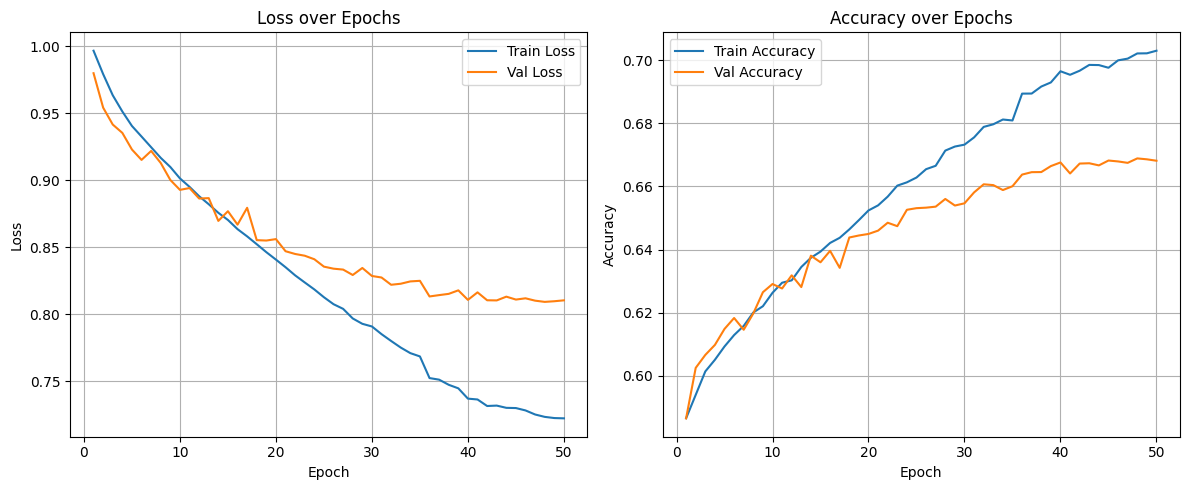

In [ ]:
plot_stats(rnn_stats)

# **Train LSTM**

In [ ]:
lstm_stats = train_model(lstm_model,train_loader,val_loader,EPOCHS)


Epoch | Train Loss | Train Acc | Val Loss | Val Acc
-------------------------------------------------------
    1 |     1.0850 |    0.5664 |   0.9631 |  0.5991  ← saved
    2 |     0.9243 |    0.6179 |   0.9015 |  0.6210  ← saved
    3 |     0.8720 |    0.6380 |   0.8699 |  0.6369  ← saved
    4 |     0.8350 |    0.6548 |   0.8446 |  0.6465  ← saved
    5 |     0.8051 |    0.6662 |   0.8309 |  0.6514  ← saved
    6 |     0.7810 |    0.6754 |   0.8169 |  0.6600  ← saved
    7 |     0.7591 |    0.6862 |   0.8118 |  0.6646  ← saved
    8 |     0.7414 |    0.6935 |   0.8014 |  0.6665  ← saved
    9 |     0.7251 |    0.7001 |   0.8019 |  0.6680  ← saved
   10 |     0.7100 |    0.7065 |   0.7989 |  0.6714  ← saved
   11 |     0.6968 |    0.7129 |   0.7926 |  0.6696
   12 |     0.6846 |    0.7174 |   0.8067 |  0.6681
   13 |     0.6723 |    0.7224 |   0.7958 |  0.6766  ← saved
   14 |     0.6616 |    0.7273 |   0.7943 |  0.6742
   15 |     0.6408 |    0.7366 |   0.8066 |  0.6766
   16 |     

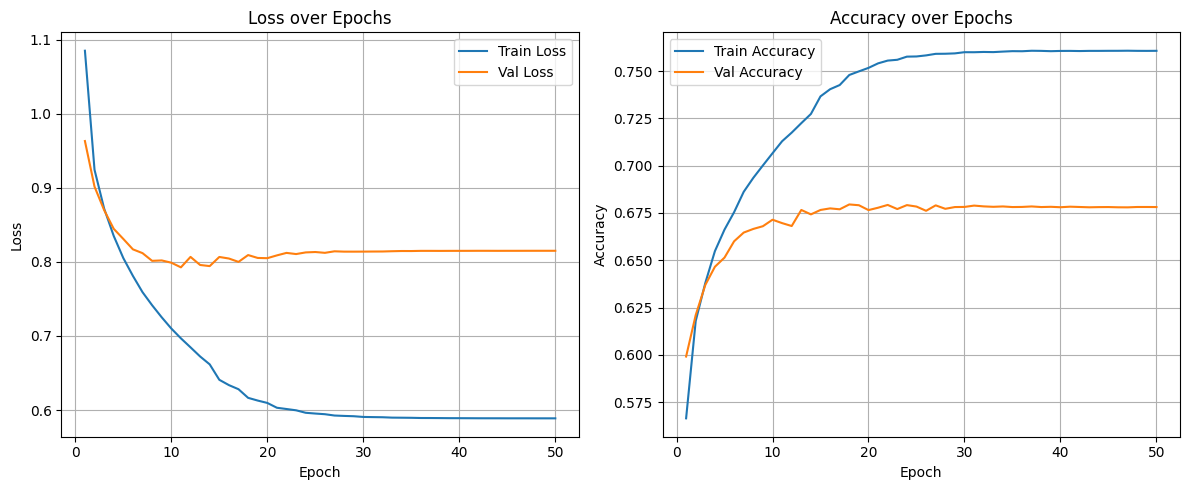

In [ ]:
plot_stats(lstm_stats)

# **Train Transformer**

In [ ]:
transformer_stats = train_model(transformer_model,train_loader,val_loader,EPOCHS)


Epoch | Train Loss | Train Acc | Val Loss | Val Acc
-------------------------------------------------------
    1 |     1.2061 |    0.5228 |   1.1739 |  0.5269  ← saved
    2 |     1.1275 |    0.5524 |   1.1091 |  0.5552  ← saved
    3 |     1.0677 |    0.5727 |   1.0648 |  0.5727  ← saved
    4 |     1.0182 |    0.5930 |   1.0333 |  0.5877  ← saved
    5 |     0.9770 |    0.6077 |   1.0016 |  0.5971  ← saved
    6 |     0.9419 |    0.6221 |   0.9819 |  0.6057  ← saved
    7 |     0.9102 |    0.6343 |   0.9760 |  0.6087  ← saved
    8 |     0.8836 |    0.6443 |   0.9505 |  0.6187  ← saved
    9 |     0.8580 |    0.6544 |   0.9377 |  0.6254  ← saved
   10 |     0.8369 |    0.6621 |   0.9402 |  0.6215
   11 |     0.8166 |    0.6713 |   0.9216 |  0.6325  ← saved
   12 |     0.7972 |    0.6780 |   0.9248 |  0.6320
   13 |     0.7777 |    0.6866 |   0.9164 |  0.6364  ← saved
   14 |     0.7614 |    0.6925 |   0.9107 |  0.6415  ← saved
   15 |     0.7442 |    0.6990 |   0.9199 |  0.6373
   

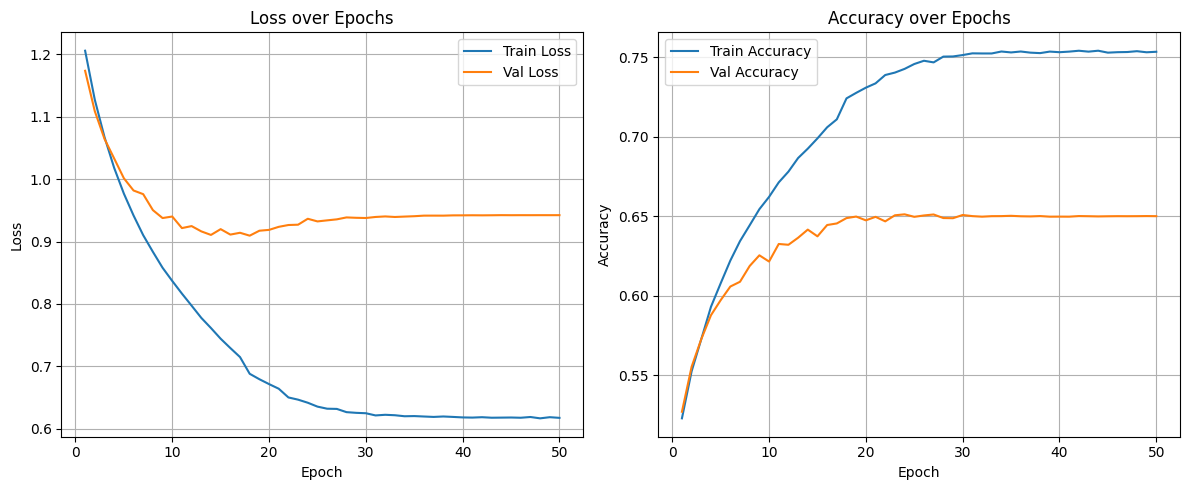

In [ ]:
plot_stats(transformer_stats)

# **Generate Submission**

In [ ]:
# Handle potential missing phrases in the test data by replacing NaN values with empty strings. Then, tokenize and pad the test phrases using the previously fitted tokenizer and padding settings.
test_na_rows = test_data['Phrase'].isna()
test_data.loc[test_na_rows, 'Phrase'] = ''

test_sequences  = tokenizer.texts_to_sequences(test_data['Phrase'])
test_padded  = pad_sequences(test_sequences,  maxlen=MAX_LEN, padding='post', truncating='post')

In [ ]:
# Define a custom PyTorch Dataset class specifically for test sequences, as it does not require labels.
class TestDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = torch.tensor(sequences, dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx]

In [ ]:
# Create an instance of the `TestDataset` using the padded test sequences and then set up a `DataLoader` for efficient batch processing of the test data.
test_dataset = TestDataset(test_padded)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [ ]:
# Put the model in evaluation mode and define a `predict` function that iterates through the test data loader, makes predictions, and returns the predicted sentiment labels.
model.eval()
@torch.no_grad()
def predict(model, loader):
    preds = []

    for x in loader:
        x = x.to(DEVICE)

        logits = model(x)
        batch_preds = torch.argmax(logits, dim=1)

        preds.extend(batch_preds.cpu().numpy())

    return preds

In [ ]:
# Generate sentiment predictions for the test dataset using the trained model and the `predict` function.
predictions = predict(rnn_model, test_loader)

In [ ]:
# Create a pandas DataFrame for submission, mapping the original 'PhraseId' from the test data to the generated 'Sentiment' predictions.
submission = pd.DataFrame({
    "PhraseId": test_data["PhraseId"],
    "Sentiment": predictions
})

In [ ]:
# Save the submission DataFrame to a CSV file named 'submission.csv', excluding the DataFrame index.
submission.to_csv("submission.csv", index=False)